In [1]:
import pandas as pd

# Load 100 cards' reviews from each user
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("card_id", "<", 100), ("duration", ">", 0), ("duration", "<=", 60_000)], columns=["elapsed_days", "duration", "rating"]
)
df.sort_values("elapsed_days", inplace=True)
df = df.sample(1_000_000)

(array([138676., 260815.,  97673.,  40146.,  48834.,  36674.,  31738.,
         23501.,  20855.,  30693.]),
 array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.]),
 <BarContainer object of 10 artists>)

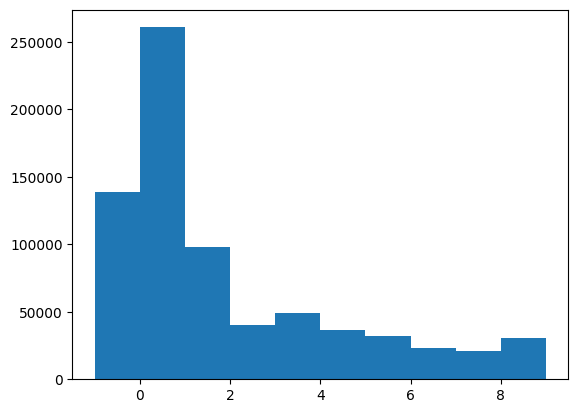

In [2]:
import matplotlib.pyplot as plt

x = df["elapsed_days"]
y = df["duration"] / 1000

plt.hist(x[x < 10])

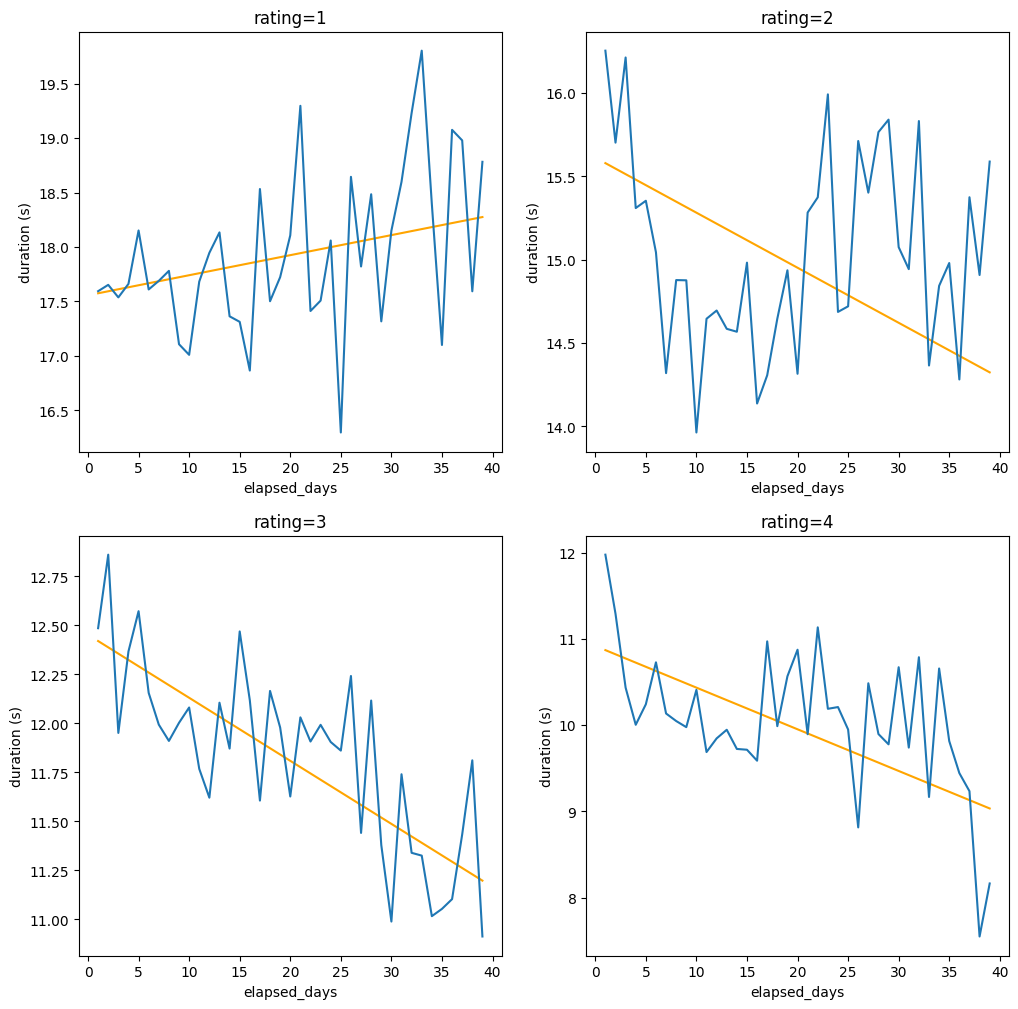

In [9]:
import numpy as np

end = 40

filtered_df = df[(df["elapsed_days"] > 0) & (df["elapsed_days"] < end)]

def plot(df, axes, label):
    x = df["elapsed_days"]
    y = df["duration"] / 1000

    c = np.polyfit(x, y, 1)
    axes.plot(np.arange(1, end), np.polyval(c, np.arange(1, end)), color="orange")
    axes.plot(np.arange(1, end), df.groupby("elapsed_days")["duration"].mean() / 1000)

    axes.set_title(f"{rating=}")
    axes.set_xlabel("elapsed_days")
    axes.set_ylabel("duration (s)")

fig = plt.figure(figsize=(12, 12))
for rating in range(1, 5):
    plot(filtered_df[filtered_df["rating"] == rating], fig.add_subplot(2, 2, rating), rating)

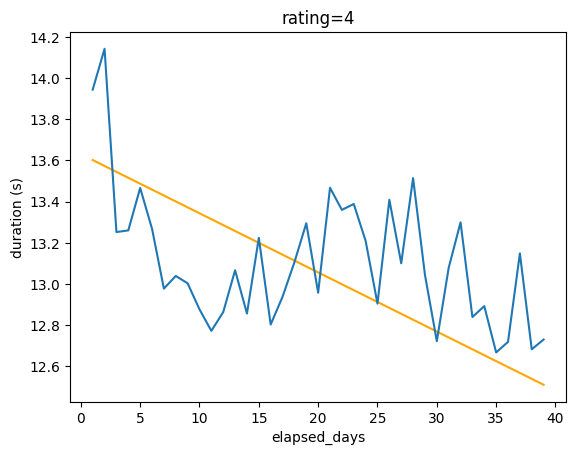

In [11]:
plot(filtered_df, plt.axes(), "all")